# Python业务分析

本Notebook使用pandas复算SQL阶段的核心经营指标，并生成月度销售、海外市场和商品表现图表。

分析口径与SQL阶段保持一致：

- 正常销售：`TransactionType == "Sale"`
- 订单量：去重后的`InvoiceNo`
- 客户分析：仅包含具有`CustomerID`的正常销售记录
- 商品分析：仅包含`ItemType == "Merchandise"`的正常销售记录
- 2011年12月为不完整月份，不参与环比分析

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}"
)

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_path = (
    project_root
    / "data"
    / "processed"
    / "transactions_clean.csv"
)

figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print("项目根目录：", project_root)
print("数据文件存在：", data_path.exists())
print("图表保存目录：", figures_dir)

项目根目录： c:\Users\a\Documents\DataAnalysisProjects\ecommerce-customer-analysis
数据文件存在： True
图表保存目录： c:\Users\a\Documents\DataAnalysisProjects\ecommerce-customer-analysis\reports\figures


In [5]:
expected_columns = [
    "SourceRow",
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
    "LineAmount",
    "Year",
    "Month",
    "HasCustomerID",
    "TransactionType",
    "ItemType",
]

df = pd.read_csv(
    data_path,
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "Description": "string",
        "CustomerID": "string",
        "Country": "string",
        "Month": "string",
        "TransactionType": "category",
        "ItemType": "category",
    },
    parse_dates=["InvoiceDate"],
)

# 与MySQL导入时的金额精度保持一致
df["LineAmount"] = df["LineAmount"].round(3)

assert list(df.columns) == expected_columns
assert df.shape == (536641, 15)
assert df["InvoiceDate"].notna().all()

print("数据形状：", df.shape)
print(
    "时间范围：",
    df["InvoiceDate"].min(),
    "至",
    df["InvoiceDate"].max()
)

display(df.head())

数据形状： (536641, 15)
时间范围： 2010-12-01 08:26:00 至 2011-12-09 12:50:00


,SourceRow,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineAmount,Year,Month,HasCustomerID,TransactionType,ItemType
0,2,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,2010-12,True,Sale,Merchandise
1,3,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,True,Sale,Merchandise
2,4,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,2010-12,True,Sale,Merchandise
3,5,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,True,Sale,Merchandise
4,6,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,2010-12,True,Sale,Merchandise


In [6]:
sales = df.loc[
    df["TransactionType"].eq("Sale")
].copy()

cancellations = df.loc[
    df["TransactionType"].eq("Cancellation")
].copy()

identified_sales = sales.loc[
    sales["CustomerID"].notna()
].copy()

merchandise_sales = sales.loc[
    sales["ItemType"].eq("Merchandise")
].copy()

customer_orders = (
    identified_sales
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

python_results = pd.Series({
    "sale_line_count": len(sales),
    "sales_order_count": sales["InvoiceNo"].nunique(),
    "identified_customer_count": (
        identified_sales["CustomerID"].nunique()
    ),
    "sales_amount": round(
        sales["LineAmount"].sum(),
        2
    ),
    "average_order_value": round(
        sales["LineAmount"].sum()
        / sales["InvoiceNo"].nunique(),
        2
    ),
    "identified_sales_amount": round(
        identified_sales["LineAmount"].sum(),
        2
    ),
    "cancellation_amount": round(
        abs(cancellations["LineAmount"].sum()),
        2
    ),
    "repeat_customer_percent": round(
        100 * customer_orders.ge(2).sum()
        / customer_orders.size,
        2
    ),
})

sql_expected = pd.Series({
    "sale_line_count": 524878,
    "sales_order_count": 19960,
    "identified_customer_count": 4338,
    "sales_amount": 10642110.80,
    "average_order_value": 533.17,
    "identified_sales_amount": 8887208.89,
    "cancellation_amount": 893979.73,
    "repeat_customer_percent": 65.58,
})

comparison = pd.DataFrame({
    "Python结果": python_results,
    "SQL结果": sql_expected,
})

comparison["差异"] = (
    comparison["Python结果"]
    - comparison["SQL结果"]
)

comparison["是否一致"] = np.isclose(
    comparison["Python结果"],
    comparison["SQL结果"],
    atol=0.01
)

display(comparison)

assert comparison["是否一致"].all()

print("Python与SQL核心指标全部一致")

,Python结果,SQL结果,差异,是否一致
sale_line_count,"524,878.00","524,878.00",0.00,True
sales_order_count,"19,960.00","19,960.00",0.00,True
identified_customer_count,"4,338.00","4,338.00",0.00,True
sales_amount,"10,642,110.80","10,642,110.80",0.00,True
average_order_value,533.17,533.17,0.00,True
identified_sales_amount,"8,887,208.89","8,887,208.89",0.00,True
cancellation_amount,"893,979.73","893,979.73",0.00,True
repeat_customer_percent,65.58,65.58,0.00,True


Python与SQL核心指标全部一致


In [7]:
# 月度销售
monthly_summary = (
    sales
    .groupby("Month")
    .agg(
        sales_order_count=("InvoiceNo", "nunique"),
        identified_customer_count=("CustomerID", "nunique"),
        sales_amount=("LineAmount", "sum"),
    )
    .sort_index()
)

monthly_summary["average_order_value"] = (
    monthly_summary["sales_amount"]
    / monthly_summary["sales_order_count"]
)

monthly_summary["month_status"] = np.where(
    monthly_summary.index == "2011-12",
    "Incomplete month",
    "Complete month",
)

complete_monthly = monthly_summary.loc[
    monthly_summary.index != "2011-12"
].copy()

complete_monthly["month_over_month_percent"] = (
    complete_monthly["sales_amount"]
    .pct_change()
    .mul(100)
)


# 国家和地区
country_summary = (
    sales
    .groupby("Country")
    .agg(
        sales_order_count=("InvoiceNo", "nunique"),
        identified_customer_count=("CustomerID", "nunique"),
        sales_amount=("LineAmount", "sum"),
    )
)

country_summary["average_order_value"] = (
    country_summary["sales_amount"]
    / country_summary["sales_order_count"]
)

country_summary["sales_amount_percent"] = (
    100
    * country_summary["sales_amount"]
    / country_summary["sales_amount"].sum()
)

overseas_top10 = (
    country_summary
    .drop(index="United Kingdom")
    .nlargest(10, "sales_amount")
)


# 商品
product_summary = (
    merchandise_sales
    .groupby("StockCode")
    .agg(
        product_description=("Description", "first"),
        quantity_sold=("Quantity", "sum"),
        sales_order_count=("InvoiceNo", "nunique"),
        sales_amount=("LineAmount", "sum"),
    )
)

top_products_by_sales = product_summary.nlargest(
    10,
    "sales_amount"
)


# 客户复购
repeat_summary = pd.Series({
    "identified_customer_count": customer_orders.size,
    "one_time_customer_count": customer_orders.eq(1).sum(),
    "repeat_customer_count": customer_orders.ge(2).sum(),
    "repeat_customer_percent": round(
        100 * customer_orders.ge(2).sum()
        / customer_orders.size,
        2
    ),
    "average_orders_per_customer": round(
        customer_orders.mean(),
        2
    ),
})

print("月度销售结果")
display(monthly_summary)

print("海外市场前10名")
display(overseas_top10)

print("商品销售额前10名")
display(top_products_by_sales)

print("客户复购结果")
display(repeat_summary)

月度销售结果


,sales_order_count,identified_customer_count,sales_amount,average_order_value,month_status
Month,,,,,
2010-12,1559,885,"821,452.73",526.91,Complete month
2011-01,1086,741,"689,811.61",635.19,Complete month
2011-02,1100,758,"522,545.56",475.04,Complete month
2011-03,1454,974,"716,215.26",492.58,Complete month
2011-04,1246,856,"536,968.49",430.95,Complete month
2011-05,1681,1056,"769,296.61",457.64,Complete month
2011-06,1533,991,"760,547.01",496.12,Complete month
2011-07,1475,949,"718,076.12",486.83,Complete month
2011-08,1361,935,"757,841.38",556.83,Complete month


海外市场前10名


,sales_order_count,identified_customer_count,sales_amount,average_order_value,sales_amount_percent
Country,,,,,
Netherlands,94,9,"285,446.34","3,036.66",2.68
EIRE,288,3,"283,140.52",983.13,2.66
Germany,457,94,"228,678.40",500.39,2.15
France,392,87,"209,625.37",534.76,1.97
Australia,57,9,"138,453.81","2,429.01",1.30
Spain,90,30,"61,558.56",683.98,0.58
Switzerland,54,21,"57,067.60","1,056.81",0.54
Belgium,98,25,"41,196.34",420.37,0.39
Sweden,36,8,"38,367.83","1,065.77",0.36


商品销售额前10名


,product_description,quantity_sold,sales_order_count,sales_amount
StockCode,,,,
22423,REGENCY CAKESTAND 3 TIER,13851,1988,"174,156.54"
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,1,"168,469.60"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,37933,2265,"106,415.23"
47566,PARTY BUNTING,18283,1685,"99,445.23"
85099B,JUMBO BAG RED RETROSPOT,48371,2089,"94,159.81"
23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,247,"81,700.92"
23084,RABBIT NIGHT LIGHT,30739,994,"66,870.03"
22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,1160,"64,875.59"
84879,ASSORTED COLOUR BIRD ORNAMENT,36362,1455,"58,927.62"


客户复购结果


identified_customer_count     4,338.00
one_time_customer_count       1,493.00
repeat_customer_count         2,845.00
repeat_customer_percent          65.58
average_orders_per_customer       4.27
dtype: float64

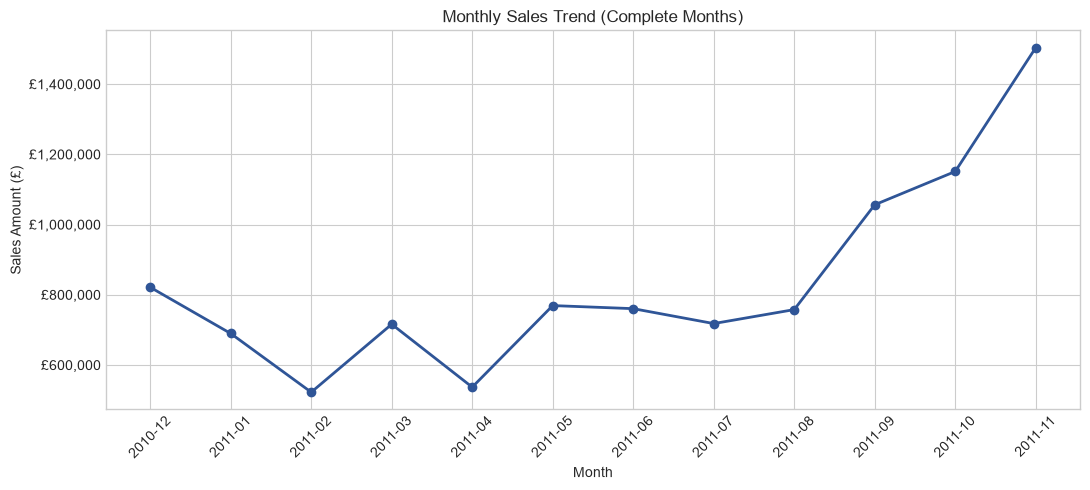

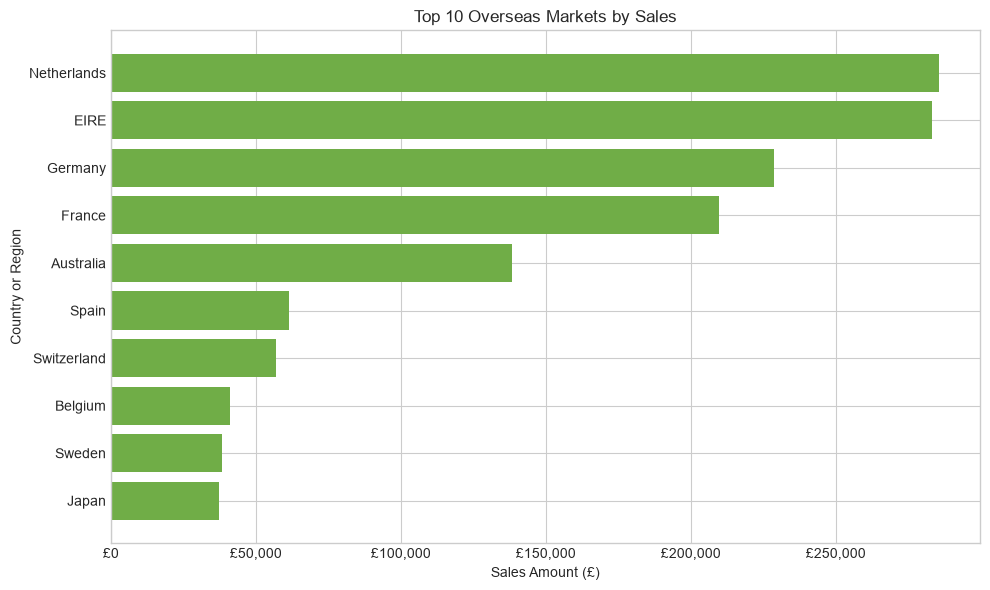

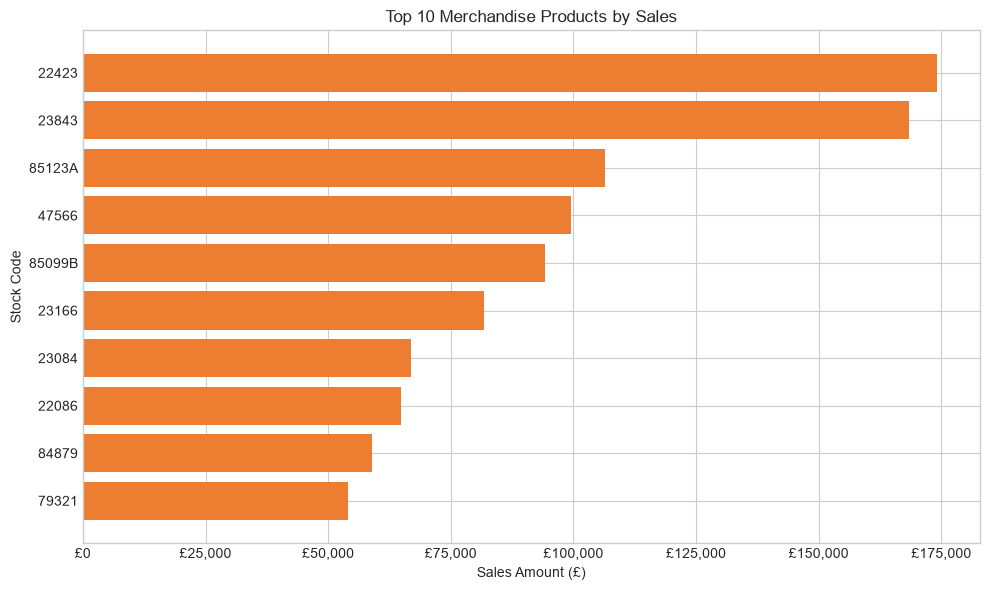

In [8]:
# 图1：完整月份销售趋势
monthly_plot = complete_monthly.reset_index()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    monthly_plot["Month"],
    monthly_plot["sales_amount"],
    marker="o",
    linewidth=2,
    color="#2F5597",
)

ax.set_title("Monthly Sales Trend (Complete Months)")
ax.set_xlabel("Month")
ax.set_ylabel("Sales Amount (£)")
ax.yaxis.set_major_formatter(
    StrMethodFormatter("£{x:,.0f}")
)
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(
    figures_dir / "monthly_sales_trend.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


# 图2：海外市场销售额前10名
overseas_plot = overseas_top10.sort_values(
    "sales_amount"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    overseas_plot.index,
    overseas_plot["sales_amount"],
    color="#70AD47",
)

ax.set_title("Top 10 Overseas Markets by Sales")
ax.set_xlabel("Sales Amount (£)")
ax.set_ylabel("Country or Region")
ax.xaxis.set_major_formatter(
    StrMethodFormatter("£{x:,.0f}")
)

fig.tight_layout()
fig.savefig(
    figures_dir / "top_overseas_markets.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


# 图3：商品销售额前10名
product_plot = top_products_by_sales.sort_values(
    "sales_amount"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    product_plot.index,
    product_plot["sales_amount"],
    color="#ED7D31",
)

ax.set_title("Top 10 Merchandise Products by Sales")
ax.set_xlabel("Sales Amount (£)")
ax.set_ylabel("Stock Code")
ax.xaxis.set_major_formatter(
    StrMethodFormatter("£{x:,.0f}")
)

fig.tight_layout()
fig.savefig(
    figures_dir / "top_products_by_sales.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [9]:
expected_figures = [
    figures_dir / "monthly_sales_trend.png",
    figures_dir / "top_overseas_markets.png",
    figures_dir / "top_products_by_sales.png",
]

assert all(path.exists() for path in expected_figures)
assert all(path.stat().st_size > 0 for path in expected_figures)
assert monthly_summary.index.is_monotonic_increasing
assert overseas_top10.index.is_unique
assert top_products_by_sales.index.is_unique

print("全部Python业务分析验证通过")

for path in expected_figures:
    print(path.name, path.stat().st_size, "bytes")

全部Python业务分析验证通过
monthly_sales_trend.png 76325 bytes
top_overseas_markets.png 49305 bytes
top_products_by_sales.png 51347 bytes
